In [ ]:
import os
os.environ["PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION"] = "no"

import matplotlib as mpl
font = {'family' : 'sans',
        'size'   : 12}

mpl.rc('font', **font)
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, LogLocator, MaxNLocator
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from utils.load_grid import latexify, descend_get, M_earth, R_earth, M_jupiter, R_jupiter

import numpy as np
from copy import deepcopy
import pandas as pd
import os
import json
import toml
from glob import glob
from scipy.interpolate import PchipInterpolator

from scipy.stats import gaussian_kde



import pandas as pd
from cmcrameri import cm

DPI=400

# THESIS_DIR = "/home2/p321409/Projects/thesis_pipeline"
# SIM_DIR = "data/scratch/"

# THESIS_DIR = "/home/harrison/Projects/thesis_pipeline"
# SIM_DIR = "data/"

THESIS_DIR = "/data/hen28/Projects/thesis_pipeline"
SIM_DIR = "data/bayesopt_recent/"



In [152]:

age_min = 1e5
age_max = 4e9


def get_var_props(key):
    """Get plot properties for key

    Arguments
    ----------
    - key, str

    Returns
    ----------
    - scale, float
    - yscl, str
    - ylim, list
    - ytck, list
    - ylbl, str
    """

    scale = 1
    yscl = "linear"
    ylim = None
    ytck = None
    ylbl = key

    # Observables
    # ---------------------
    if key == "Time":
        scale = 1
        ylbl = "Time\n[yr]"
        yscl = "log"
    elif key == "M_planet":
        scale = M_earth
        ytck  = [1, 2, 3]
        ylim  = [0.8, 3.2]
        ylbl  = "Mass\n" + r"/M$_{\oplus}$"
    elif key == "R_obs":
        scale = R_earth
        ytck = [1, 1.5, 2]
        ylim = [0.6, 2.4]
        ylbl  = "Radius\n" + r"/R$_{\oplus}$"
    elif key == "g_obs":
        scale = 1.0
        ytck = [8.0, 12.0, 16.0, 20.0]
        ylim = [5.0, 22.1]
        ylbl  = r"g$_{\rm obs}$" + "\n" + r"m/s$^2$"
    elif key == "T_obs":
        scale = 1e3
        ylim = [0.4, 1.4]
        ylbl  = r"T$_{\rm obs}$" + "\nkK"
        ytck = [0.8, 1.0, 1.2]
    elif key == "atm_kg_per_mol":
        scale = 1e-3
        ylim = [8, 40]
        ylbl = r"$\mu_{\rm obs}$"+"\ng/mol"
        ytck = [5, 15, 25, 35]
    elif key in ["C/O_atm", "S/O_atm", "O/H_atm"]:
        scale = 1
        yscl = "log"
        ylim = [2e-2, 2e1]
        ylbl = key.split("_")[0]
    elif key.endswith("_vmr"):
        scale = 1e-2
        ylbl = latexify(key.split("_")[0]) + "\n%VMR"
        ylim = [-2, 102.0]
        ytck = [0, 25, 50, 75]
    elif key == "P_surf":
        scale = 1e3
        ylim = [0, 1e3]
        ylbl = r"P$_{\rm surf}$" + "\nkbar"
        yscl = "symlog"
        ytck = [1, 10, 100, 1000]
    elif key == "Phi_global":
        scale = 1e-2
        ylim = [-5, 105.0]
        ylbl = "Melt\n[%]"
        ytck = [0, 40, 80,]
    elif key == "T_surf":
        scale = 1e3
        ylim = [-0.02, 3.0]
        ylbl  = r"T$_{\rm surf}$" + "\nkK"
        ytck = [0.5, 1.0, 1.5, 2.0]

    # Parameters
    # ---------------------
    elif key == "interior_energetics.boundary.T_p_0":
        scale = 1e3
        ylbl  = r"T${\rm _{pot}^{ini}}$" + "\nkK"
        ytck = [2.0, 2.5, 3.0, 3.5, 4.0]
    elif key == "params.stop.time.maximum":
        ylbl  = "Age\n" + r"[yr]"
        yscl = "log"
        ylim = [age_min / 5, age_max * 5]
    elif key == "planet.semimajoraxis":
        ylbl  = "SMA\n" + r"[AU]"
        ytck = [0, 0.05, .1, 0.15, 0.2, 0.25]
    elif key == "planet.mass_tot":
        ylbl  = r"$M^{\rm ini}$" +"\n"+ r"/M$_{\oplus}$"
        ytck  = [1, 2, 3]
        ylim  = [0.8, 3.2]
    elif key == 'interior_struct.core_frac':
        scale = 1e-2
        ylbl = "Core\n[%]"
        ytck = [20, 40, 60, 80]
    elif key == 'outgas.fO2_shift_IW':
        ylbl = r"$\Delta$" + "IW"
        ytck = [-4, -2, 0, 2, 4]
        ylim = [-4.5, 4.5]
    elif key == "planet.elements.H_budget": # oceans
        scale = 1.0
        yscl = "log"
        ylbl = "Initial\n" + r"H$_{\rm ppmw}$"
    elif key == "planet.elements.C_budget": # C/H
        ylbl = "Initial\nC/H"
        ytck = [0, 2, 4]
        ylim = [-0.1, 4.5]
    elif key == "planet.elements.S_budget": # S/H
        ylbl  = "Initial\nS/H"
        ytck = [0, 2, 4]
        ylim = [-0.1, 4.5]
    elif key == "objective":
        ylbl = "Objective"

    return scale, yscl, ylim, ytck, ylbl

In [3]:
%matplotlib inline
# %config InlineBackend.figure_format='retina'

# %matplotlib widget

In [4]:
def get_bo_run(output_dir):

    output_dir = os.path.abspath(output_dir)
    # print("    Reading BO run from", output_dir)

    # check folder exists
    if not os.path.isdir(output_dir):
        print(f"Folder {output_dir} does not exist.")
        return None

    # Read BO config file
    config_path = os.path.join(output_dir, "copy.infer.toml")
    infer_conf = toml.load(config_path)
    obs = infer_conf['observables']
    prs = infer_conf['parameters']

    # Extract log of BO run
    if not os.path.isfile(os.path.join(output_dir, "logs.csv")):
        print(f"Log file not found in {output_dir}.")
        return None
    fpath = os.path.join(output_dir, "logs.csv")
    log = []
    best_obj = -np.inf
    with open(fpath, 'r') as f:
        for line in f.readlines():
            if '{' not in line:
                continue
            line = line.replace("'", '"').replace("None", "1.0")[1:-2]
            json_line = json.loads(line) # parse json into dict
            log.append(json_line)

            if json_line['y_value'] > best_obj:
                best_obj = json_line['y_value']

    # Mark best worker
    is_best = np.full(len(log), False, dtype=bool)
    for i, run in enumerate(log):
        if run['y_value'] == best_obj:
            is_best[i] = True
    print("        best worker:", np.where(is_best)[0], "with y =", best_obj)

    # For each worker, read helpfile
    helps = []
    confs = []
    for run in log:
        wk = run['worker']
        id = run['task_id']

        help_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "runtime_helpfile.csv")
        if not os.path.isfile(help_path):
            print(f"Helpfile not found for worker {wk}, task {id}.")
            continue
        helps.append(pd.read_csv(help_path, delimiter=r"\s+"))

        conf_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "input.toml")
        confs.append(toml.load(conf_path))

    # Package into dict
    bo_run = {
        "config": infer_conf,
        "log": log,
        "helps": helps,
        "confs": confs,
        "obs": obs,
        "prs": prs,
        "is_best": is_best,
    }
    return bo_run

def get_gt_run(gt_dir):

    # Read GT config file
    config_path = os.path.join(gt_dir, "init_coupler.toml")
    gt_conf = toml.load(config_path)

    # Read GT helpfile
    help_path = os.path.join(gt_dir, "runtime_helpfile.csv")
    help_path = os.path.abspath(help_path)
    print("Reading GT helpfile from", help_path)
    gt_help = pd.read_csv(help_path, delimiter=r"\s+")

    gt_run = {
        "config": gt_conf,
        "help": gt_help,
    }
    return gt_run

bo_suffixes = ('sn', 'se', 'tr')

# Read ground truth config and results
ground_truth  = {suf: get_gt_run(f"{SIM_DIR}/bayesopt_{suf}/") for suf in bo_suffixes}

# Plotting parameters
bo_cols = ('tab:blue', 'tab:orange', 'tab:green')
bo_tits = ('Sub-Neptune', 'Super-Earth', 'Terrestrial')


Reading GT helpfile from /data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_sn/runtime_helpfile.csv
Reading GT helpfile from /data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_se/runtime_helpfile.csv
Reading GT helpfile from /data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_tr/runtime_helpfile.csv


In [5]:
# Read inference results

def load_bo_data(controls):
    bo_data = {}
    for run in glob("bayesopt_infer_*/", root_dir=SIM_DIR):
        print(f"Found {run}", end='')

        parts = run.replace("/","").split("_")[2:]
        suf = parts[0]
        ker = parts[1]
        acq = parts[2]
        wrk = parts[3]
        stp = parts[4]

        skip = False
        skip |= ("suf" in controls) and (controls["suf"] != suf)
        skip |= ("ker" in controls) and (controls["ker"] != ker)
        skip |= ("acq" in controls) and (controls["acq"] != acq)
        skip |= ("wrk" in controls) and (controls["wrk"] != wrk)
        skip |= ("stp" in controls) and (controls["stp"] != stp)

        if skip:
            print(f"    skipping")
            continue
        else:
            print(f"    pl={suf}  kernel={ker}   acqf={acq}   work={wrk}  step={stp}")

        key = ".".join([suf, ker, acq, wrk, stp])
        print("    key=",key)

        dir = os.path.abspath(os.path.join(SIM_DIR, run))
        print("    dir=", {dir})

        bo_data[key] = get_bo_run(dir)

    return bo_data


controls = {
    "acq": "lei",
    "wrk": "5",
    "stp": "100",
}
bo_data = load_bo_data(controls)

obs_list = list(list(bo_data.values())[0]['obs'].keys())
prs_list = list(list(bo_data.values())[0]['prs'].keys())
print("Done")

Found bayesopt_infer_se_mat12_lei_5_100/    pl=se  kernel=mat12   acqf=lei   work=5  step=100
    key= se.mat12.lei.5.100
    dir= {'/data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_infer_se_mat12_lei_5_100'}
        best worker: [61] with y = -0.17068461903365628
Found bayesopt_infer_sn_mat12_lei_5_100/    pl=sn  kernel=mat12   acqf=lei   work=5  step=100
    key= sn.mat12.lei.5.100
    dir= {'/data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_infer_sn_mat12_lei_5_100'}
        best worker: [95] with y = -0.34568817294240833
Found bayesopt_infer_tr_mat12_lei_10_100/    skipping
Found bayesopt_infer_tr_mat12_lei_15_100/    skipping
Found bayesopt_infer_tr_mat12_lei_3_100/    skipping
Found bayesopt_infer_tr_mat12_lei_5_100/    pl=tr  kernel=mat12   acqf=lei   work=5  step=100
    key= tr.mat12.lei.5.100
    dir= {'/data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_infer_tr_mat12_lei_5_100'}
        best worker: [68] with y = 1.330308

## Radius period plot

In [124]:
KDE_ALPHA_MIN = 0.05
KDE_ALPHA_MAX = 0.80

def _kde2d(ax, x, y, log_x=False, log_y=False, n_levels=5, zorder=1, col='grey'):
    """2D KDE contours with independent log/linear transform per axis."""
    xd = np.log10(np.asarray(x, float)) if log_x else np.asarray(x, float)
    yd = np.log10(np.asarray(y, float)) if log_y else np.asarray(y, float)
    mask = np.isfinite(xd) & np.isfinite(yd)
    xd, yd = xd[mask], yd[mask]
    if len(xd) < 20:
        return
    kde = gaussian_kde(np.vstack([xd, yd]))
    pad_x = 0.02 * (xd.max() - xd.min())
    pad_y = 0.02 * (yd.max() - yd.min())
    xi = np.linspace(xd.min() - pad_x, xd.max() + pad_x, 200)
    yi = np.linspace(yd.min() - pad_y, yd.max() + pad_y, 200)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
    z_vals = Zi[Zi > Zi.max() * 0.01]
    if len(z_vals) == 0:
        return
    levels = np.quantile(z_vals, np.linspace(0.0, 1.0, n_levels + 1))
    Xp = 10**Xi if log_x else Xi
    Yp = 10**Yi if log_y else Yi
    alphas = np.linspace(KDE_ALPHA_MIN, KDE_ALPHA_MAX, n_levels)
    for k in range(n_levels):
        lo = levels[k]
        hi = levels[k + 1] if k + 1 < n_levels else Zi.max() * 1.01
        ax.contourf(
            Xp,
            Yp,
            Zi,
            levels=[lo, hi],
            colors=[col],
            alpha=alphas[k],
            zorder=zorder,
        )  # noqa: F405
    ax.contour(
        Xp,
        Yp,
        Zi,
        levels=levels,
        colors=[col],  # noqa: F405
        linecolors=['k'],
        linewidths=0.3,
        alpha=0.30,
        zorder=zorder,
    )


/tmp/ipykernel_400342/1176406449.py:1: DtypeWarning: Columns (0: molecules, 1: star_detected_disc, 2: star_magnetic_field) have mixed types. Specify dtype option on import or set low_memory=False.
  exo_raw = pd.read_csv(f"{THESIS_DIR}/data/exoplanet_eu.csv",delimiter=',')
/tmp/ipykernel_400342/1143319410.py:38: UserWarning: The following kwargs were not used by contour: 'linecolors'
  ax.contour(


Solar system body Mercury: x=88.00, y=0.38
Solar system body Venus: x=224.70, y=0.95
Solar system body Earth: x=365.20, y=1.00
Solar system body Mars: x=687.00, y=0.53
Solar system body Uranus: x=30589.00, y=4.01
Solar system body Neptune: x=59800.00, y=3.88
0     1.533247e+07
1     1.533247e+07
2     1.532818e+07
3     1.532817e+07
4     1.532817e+07
5     1.533239e+07
6     1.533217e+07
7     1.533198e+07
8     1.533148e+07
9     1.533000e+07
10    1.532552e+07
11    1.531134e+07
12    1.526791e+07
13    1.514651e+07
14    1.481463e+07
15    1.451477e+07
16    1.412487e+07
17    1.367508e+07
18    1.328093e+07
19    1.292252e+07
20    1.262768e+07
21    1.224638e+07
22    1.222760e+07
Name: R_obs, dtype: float64
SN ground truth
    initial: 9.93 days, 2.42 R_earth
    final:   9.93 days, 1.93 R_earth
0     9.738846e+06
1     9.738846e+06
2     9.738846e+06
3     9.738846e+06
4     9.738846e+06
5     9.738842e+06
6     9.738825e+06
7     9.738800e+06
8     9.738253e+06
9     9.738623e

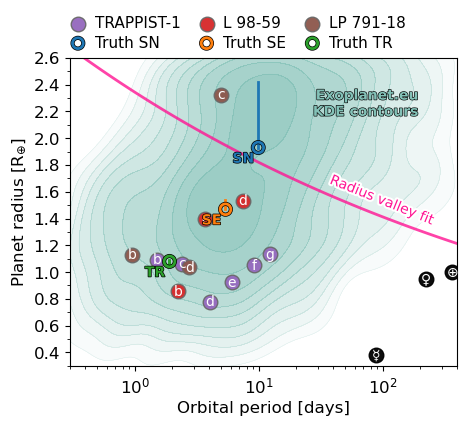

In [150]:
exo_raw = pd.read_csv(f"{THESIS_DIR}/data/exoplanet_eu.csv",delimiter=',')
exo_dat = exo_raw.loc[exo_raw['planet_status'] == 'Confirmed']

exo_named = [["TRAPPIST-1 b","TRAPPIST-1 c", "TRAPPIST-1 d", "TRAPPIST-1 e", "TRAPPIST-1 f", "TRAPPIST-1 g"],
             ["L 98-59 b", "L 98-59 c", "L 98-59 d", "L 98-59 e"],
            #  ["K2-18 b",],
             ["LP 791-18 b", "LP 791-18 c", "LP 791-18 d"],
            #  ["55 Cnc Ae"],
            #  ["TOI-270 d"]
            ]

exo_colors = [
    "tab:purple", "tab:red", "tab:brown", "blue", "grey", "green",
]

fig_ratio = tuple(np.array([4.2,4])*1.1)

named_s = 110     # point size
named_a = 0.95    # alpha
fs = 10      # font size

col_exoeu = "#83C1B7"

leg_args = {
    "handletextpad" : 0.2,
    "frameon" :       False,
    "labelspacing":   0.3,
    "columnspacing":  0.8,
    "handlelength":   1.8
}

solar_sys_file = open(f"{THESIS_DIR}/data/solar_system.tsv",'r')
ss_lines = solar_sys_file.readlines()
solar_sys_file.close()

solar_system = {}

# Add bodies
for i,h in enumerate(ss_lines[1].split()[1:]):
    k = h.capitalize()
    solar_system[k] = {"index":i,"name":k}

# For each body
for k in solar_system.keys():
    i = solar_system[k]["index"]

    # For each parameter
    for l in ss_lines[2:]:
        split = l.split()
        param = str(split[0])
        val   = split[i+1]

        if (param == "Symbol"):
            solar_system[k]["symbol"] = str(val)
        else:
            val = float(val)
            match param:
                case "Mass(10^24kg)":
                    solar_system[k]["mass"] = val / 5.97  # M_earth
                case "Diameter(km)":
                    solar_system[k]["radius"] = val / 12756# R_earth
                case "MeanTemperature(C)":
                    solar_system[k]["temp_calculated"] =  val + 273.15 # K
                case "OrbitalPeriod(days)":
                    solar_system[k]["orbital_period"] = val   # day
                case "DistancefromSun(10^6km)":
                    solar_system[k]["semi_major_axis"] = val / 149.6  # AU
                case "OrbitalEccentricity":
                    solar_system[k]["eccentricity"] = val

fig,ax = plt.subplots(1,1,figsize=(5,4))

ax.set_xlabel("Orbital period [days]")
ax.set_xscale("log")
xlim = [0.3, 400]
ax.set_xlim(xlim)

ax.set_ylabel(r"Planet radius [R$_{\oplus}$]")
ylim = [0.3,2.6]
ax.set_ylim(ylim)
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.2))


exo_sub = deepcopy(exo_dat)
exo_mask = exo_sub["orbital_period"].between(xlim[0], xlim[1]) & exo_sub["radius"].between(ylim[0]*R_earth/R_jupiter, ylim[1]*R_earth/R_jupiter)
exo_sub = exo_sub.loc[exo_mask]
xv = exo_sub["orbital_period"].values
yv = exo_sub["radius"].values * R_jupiter / R_earth
_kde2d(ax, xv, yv, log_x=True, log_y=False, col=col_exoeu, zorder=1, n_levels=10)
# ax.scatter(exo_sub["orbital_period"],exo_sub["radius"]* R_jupiter / R_earth,
        #    s=5, alpha=0.5, color='gray', edgecolors='none', rasterized=True)

for p in solar_system.values():

    # Skip some
    skip = ["Moon","Jupiter","Pluto","Saturn"]
    if (p["name"] in skip):
        continue

    x =  p["orbital_period"]
    y =  p["radius"]
    print(f"Solar system body {p['name']}: x={x:.2f}, y={y:.2f}")
    if not (ylim[0] <= y <=  ylim[1]):
        continue
    if not (xlim[0] <= x <=  xlim[1]):
        continue

    ax.scatter(x, y, s=named_s,     color='black',zorder=2, alpha=named_a)
    ax.text(x,    y, p["symbol"][0],color='white',zorder=4, horizontalalignment='center', verticalalignment='center', fontsize=fs)


for j,s in enumerate(exo_named):
    col = exo_colors[j]
    for i,p in enumerate(s):
        if i == 0:
            lbl = p[:-2]
        else:
            lbl = None
        row = exo_dat.loc[exo_dat['name'] == p].iloc[0]

        x = row["orbital_period"]
        y = row["radius"]* R_jupiter / R_earth

        a = ax.scatter(x,y, s=named_s, label=lbl, alpha=named_a, zorder=3, color=col, lw=1, ec='dimgrey')
        ax.text(x,y,p[-1],color='white',zorder=4, horizontalalignment='center', verticalalignment='center', fontsize=fs)

# Plot radius valley
#   https://academic.oup.com/mnras/article/519/3/4056/6969428
#   Equation 4
def radval(p):
    logp = np.log10(p)
    m = -0.11
    c = 0.37
    return 10**(m*logp + c)
x_rv = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), 60)
y_rv = [radval(x) for x in x_rv]
ax.plot(x_rv, y_rv, c='deeppink', lw=2, alpha=0.8)
ax.annotate("Radius valley fit", xy=(x_rv[-5], y_rv[-5]), xytext=(0, 5), textcoords='offset points',
            path_effects=[pe.Stroke(linewidth=3, foreground='white'), pe.Normal()],
            color='deeppink', fontsize=fs, rotation=-22, ha='right', va='bottom', rotation_mode='anchor')

# plot ground truth points
for suf, gt in ground_truth.items():
    gt_x = gt["help"]["orbital_period"] / (24*3600)
    gt_y = gt["help"]["R_obs"] / R_earth
    print(gt["help"]["R_obs"])
    col = bo_cols[bo_suffixes.index(suf)]
    ax.plot(gt_x, gt_y, zorder=5, color=col, lw=2)

    print(f"{suf.upper()} ground truth")
    print(f"    initial: {gt_x.iloc[0]:.2f} days, {gt_y.iloc[0]:.2f} R_earth")
    print(f"    final:   {gt_x.iloc[-1]:.2f} days, {gt_y.iloc[-1]:.2f} R_earth")
    an_x = gt_x.iloc[-1]
    an_y = gt_y.iloc[-1]
    ax.scatter(an_x, an_y, s=60, lw=2,
               edgecolor=col, color='none', zorder=7,
               path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()],
               label=f"Truth {suf.upper()}")

    ax.annotate(suf.upper(), xy=(an_x, an_y),
                xytext=(-3, -3), textcoords='offset points',
                zorder=7,
                fontweight='bold', path_effects=[pe.Stroke(linewidth=1, foreground='k'), pe.Normal()],
                color=col, fontsize=fs, ha='right', va='top')

ax.text(0.9, 0.9, "Exoplanet.eu\nKDE contours", 
        color=col_exoeu,
        transform=ax.transAxes, fontsize=fs, fontweight='bold', 
        ha='right', va='top', 
        path_effects=[pe.Stroke(linewidth=0.9, foreground='k'), pe.Normal()])

handles, labels = ax.get_legend_handles_labels()
handles = np.reshape(handles, (2,3)).T.flatten() # transpose legend
labels = np.reshape(labels, (2,3)).T.flatten()
leg = ax.legend(handles, labels, loc='lower left', bbox_to_anchor=(-0.05,0.98), **leg_args, ncols=3, fontsize=11)


fig.savefig("output/exoplanets.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.02)
plt.show()


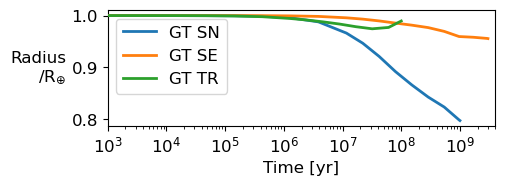

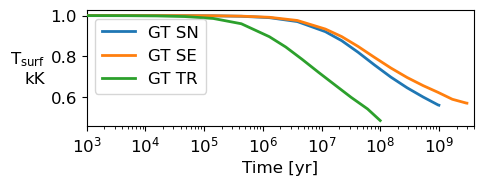

In [21]:
# plot variable over time for each GT run

for var in ["R_obs", "T_surf"]:

    fig, ax = plt.subplots(1,1,figsize=(5,1.5))

    for suf, gt in ground_truth.items():
        gt_x = gt["help"]["Time"]
        gt_y = gt["help"][var] / get_var_props(var)[0]
        gt_y /= gt_y.iloc[0]  # normalize to initial value
        col = bo_cols[bo_suffixes.index(suf)]
        ax.plot(gt_x, gt_y, zorder=5, color=col, lw=2, label=f"GT {suf.upper()}")

    ax.set_xlabel("Time [yr]")
    ax.set_xscale("log")
    ax.set_xlim(left=age_min, right=age_max)
    ax.set_ylabel(get_var_props(var)[4], rotation=0, ha='right', va='center')
    ax.set_yscale(get_var_props(var)[1])
    ax.legend()
    plt.show()

## Plot simulations resolving towards observables

In [8]:
print("\n".join(bo_data.keys()))

se.mat12.lei.5.100
sn.mat12.lei.5.100
tr.mat12.lei.5.100
tr.mat32.lei.5.100
tr.mat52.lei.5.100
tr.rbf.lei.5.100


Observables: ['R_obs', 'T_obs', 'g_obs', 'atm_kg_per_mol', 'C/O_atm', 'S/O_atm', 'O/H_atm']
R_obs
    sn   best objective for this BO: -0.34568817294240833
    se   best objective for this BO: -0.17068461903365628
    tr   best objective for this BO: 1.330308054574275
T_obs
    sn   best objective for this BO: -0.34568817294240833
    se   best objective for this BO: -0.17068461903365628
    tr   best objective for this BO: 1.330308054574275
g_obs
    sn   best objective for this BO: -0.34568817294240833
    se   best objective for this BO: -0.17068461903365628
    tr   best objective for this BO: 1.330308054574275
atm_kg_per_mol
    sn   best objective for this BO: -0.34568817294240833
    se   best objective for this BO: -0.17068461903365628
    tr   best objective for this BO: 1.330308054574275
C/O_atm
    sn   best objective for this BO: -0.34568817294240833
    se   best objective for this BO: -0.17068461903365628
    tr   best objective for this BO: 1.330308054574275
S/O_atm
    

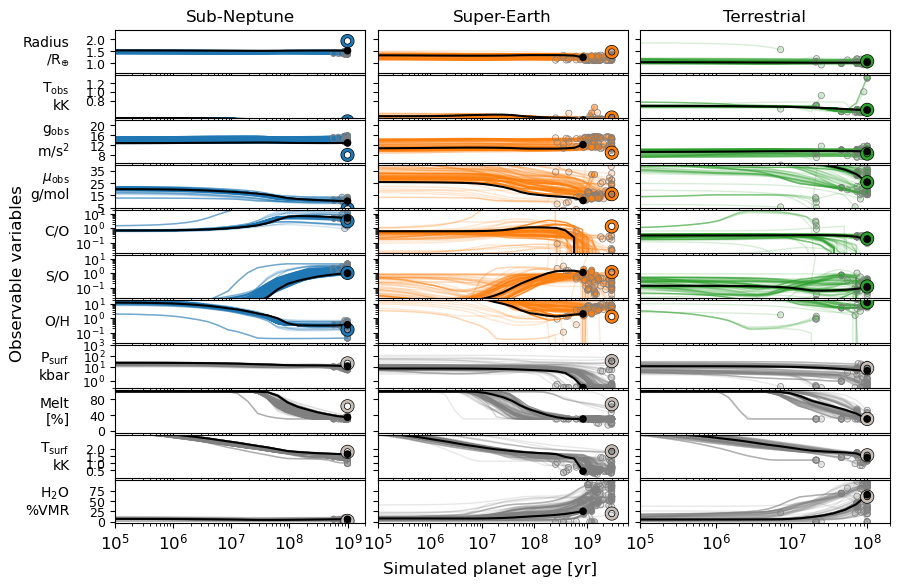

Done


In [153]:
def plot_bo_evolve():

    print("Observables:", obs_list)
    yvars = obs_list +['P_surf', 'Phi_global', 'T_surf', 'H2O_vmr']
    N_yv = len(yvars)

    show_cases = [f"{suf}.mat12.lei.5.100" for suf in ("sn","se","tr")]
    N_bo = len(show_cases)

    fig,axs = plt.subplots(N_yv,N_bo,figsize=(10,2+N_yv*0.4))

    # for each y-variable
    for iax in range(N_yv):
        key = yvars[iax]
        print(key)

        scale, yscl, ylim, ytck, ylbl = get_var_props(key)

        # for each BO run
        for jax, bo_key in enumerate(show_cases):
            suf = bo_key.split(".")[0]
            print("    "+suf, end='')

            ax = axs[iax, jax]

            bo = bo_data[bo_key]
            if bo is None:
                print(f"    BO run {bo_key} not found.")
                continue
            helps      = bo['helps']
            confs      = bo['confs']
            obs_this   = bo['obs']  # observables for this BO run
            prs_this   = bo['prs']  # parameters ranges for this BO run

            is_observable = key in obs_list
            col = bo_cols[jax]

            # get best objective value for this BO run
            best_obj = max(run['y_value'] for run in bo['log'])
            print("   best objective for this BO:", best_obj)

            # plot simulations from this BO run
            x_end = []
            y_end = []
            c_end = []
            for isim in range(len(helps)):
                help = helps[isim]
                conf = confs[isim]
                x = help['Time']
                y = help[key] / scale

                # value of objective (best=1)
                alp = max(0.2, bo['log'][isim]['y_value'] - best_obj+1) * 0.9

                if bo['is_best'][isim]:
                    col_sim = 'k'
                    lw_sim = 1.5
                    zorder_sim = 5
                    alp = 1.0
                else:
                    if is_observable:
                        col_sim = col
                    else:
                        col_sim = 'grey'
                    lw_sim = 1
                    zorder_sim = 1

                # sort x and remove duplicate times
                mask = np.argsort(x) & (x>1)
                x = np.array(x)[mask]
                y = np.array(y)[mask]

                # interpolate to get smoother lines
                if 3 < len(x) < 40:
                    x_plt = np.logspace(np.log10(min(x)), np.log10(max(x)), 40)
                    y_plt = PchipInterpolator(x, y)(x_plt)
                else:
                    x_plt = x
                    y_plt = y
                ax.plot(x_plt, y_plt, color=col_sim, alpha=alp, linewidth=lw_sim, zorder=zorder_sim)

                x_end.append(x[-1])
                y_end.append(y[-1])
                r,g,b = mpl.colors.to_rgb(col_sim)
                c_end.append((r, g, b, alp))

                # is best
                if bo['is_best'][isim]:
                    ax.scatter(x[-1], y[-1], color='k', edgecolor='none', s=30, zorder=21)

            # add scatter point at end of simulation
            ax.scatter(x_end, y_end, color=c_end, edgecolor='grey', s=20, lw=0.5, zorder=zorder_sim+1)

            # plot truths
            if not is_observable:
                col = "#c6beb6"
            obs_tru = ground_truth[suf]['help'][key].iloc[-1] / scale
            obs_age = descend_get(ground_truth[suf]['config'], 'params.stop.time.maximum')
            ax.scatter(obs_age, obs_tru, color='none', edgecolor=col, s=50, zorder=20, lw=2,
                    path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])

            ax.set_xscale("log")
            ax.set_xticks([1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9])
            ax.set_xlim(left=age_min, right=np.amax(x_end)*2.0)
            ax.set_ylim(ylim)
            ax.set_yscale(yscl)
            if ytck is not None:
                ax.set_yticks(ytck)
            if jax == 0:
                ax.set_ylabel(ylbl, rotation=0, ha='right', va='center', fontsize=10)
                ax.tick_params(axis='y', which='major', labelsize=9)
            else:
                ax.set_yticklabels([])

            if iax == 0:
                ax.set_title(bo_tits[jax], fontsize=font["size"])
            if iax == N_yv - 1:
                # ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g"))
                pass
            else:
                ax.set_xticklabels([])

    fig.supylabel("Observable variables", fontsize=font["size"])
    fig.supxlabel("Simulated planet age [yr]", va='top', fontsize=font["size"], y=0.05)
    fig.align_ylabels()
    fig.subplots_adjust(wspace=0.05, hspace=0.05)

    plt.show()
    fig.savefig("output/bo_evolve.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.01)

plot_bo_evolve()
print("Done")

## Plot retrieval resolving ground truth parameters

Parameters: ['interior_struct.core_frac', 'outgas.fO2_shift_IW', 'planet.elements.H_budget', 'planet.elements.C_budget', 'planet.elements.S_budget']
interior_struct.core_frac
     sn
     se
     tr
outgas.fO2_shift_IW
     sn
     se
     tr
planet.elements.H_budget
     sn
     se
     tr
planet.elements.C_budget
     sn
     se
     tr
planet.elements.S_budget
     sn
     se
     tr


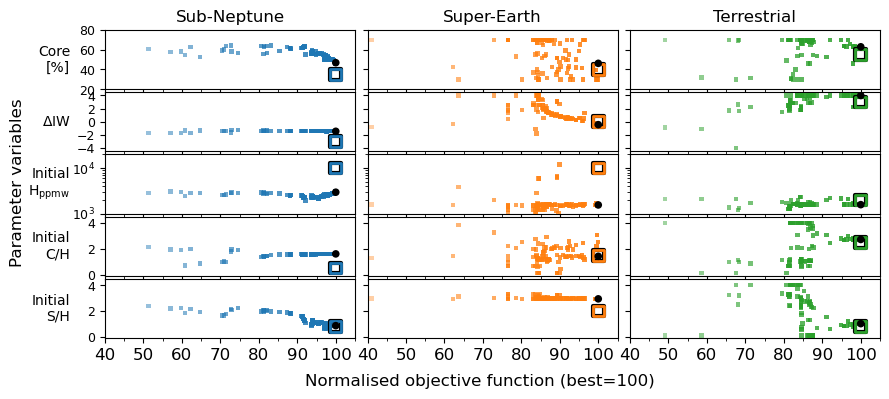

Done


In [157]:
def plot_bo_converge(xvar='clock'):
        
    print("Parameters:", prs_list)
    # prs_list.extend(["objective"])

    show_cases = [f"{suf}.mat12.lei.5.100" for suf in ("sn","se","tr")]

    N_pa = len(prs_list)
    N_bo = len(show_cases)

    fig,axs = plt.subplots(N_pa,N_bo,figsize=(10,2+N_pa*0.4))

    # for each parameter
    for iax in range(N_pa):
        key = prs_list[iax]
        print(key)

        scale, yscl, ylim, ytck, ylbl = get_var_props(key)
        if ylim is None:
            ylim = np.array([bo_data[show_cases[0]]['config']['parameters'][key]][0]) / scale

        # for each BO run
        global bo_suffixes
        for jax, bo_key in enumerate(show_cases):
            suf = show_cases[jax].split(".")[0]
            print("    ", suf)

            ax = axs[iax, jax]

            bo = bo_data[bo_key]
            log = bo['log']
            helps      = bo['helps']
            confs      = bo['confs']
            obs_this   = bo['obs']  # observables for this BO run
            prs_this   = bo['prs']  # parameters ranges for this BO run

            N_wk = np.amax([run['worker'] for run in log]) + 1
            col = bo_cols[jax]

            # get xmin from all cases
            tmin = np.inf
            xmax = -np.inf
            jbest = -np.inf
            jwrst = np.inf
            for isim in range(len(log)):

                jvalue = log[isim]['y_value']
                if jvalue < -19.9:
                    continue

                jbest = max(jbest, log[isim]['y_value'])
                jwrst = min(jwrst, log[isim]['y_value'])
                if xvar == 'clock':
                    tmin = min(tmin, log[isim]['start_time'])
                    

            # get values for each worker process
            for isim in range(len(log)):

                jvalue = log[isim]['y_value']
                if jvalue < -19.9:
                    continue

                jnorm = (jvalue - jwrst) / (jbest - jwrst) * 100

                if xvar == 'clock':
                    x0 = (log[isim]['start_time'] - tmin) / 60
                    x1 = (log[isim]['end_time'] - tmin) / 60
                    xmax = max(xmax, x1)
                    xfmt = "%.0f"
                    xlbl = "Retrieval clock time [minutes]"

                elif xvar == 'objective':
                    x0 = None
                    x1 = jnorm
                    xmax = max(xmax, x1)
                    xfmt = "%.0f"
                    xlbl = "Normalised objective function (best=100)"

                else:
                    raise ValueError(f"Unknown xvar '{xvar}'")

                yv = descend_get(confs[isim], key) / scale
                alp = max(0.1, jnorm/100) * 0.9

                if x0 is not None:
                    ax.plot([x0,x1], [yv, yv], color=col, alpha=alp, zorder=10, lw=0.5, linestyle='-')
                ax.scatter(x1, yv, color=col, alpha=alp, edgecolor='none',
                        s=10, zorder=10, lw=0.5, marker='s')

                # is best?
                if bo['is_best'][isim]:
                    ax.scatter(x1, yv, color='k', edgecolor='none', s=30, zorder=101)

            # plot true value on this parameter
            par_tru = descend_get(ground_truth[suf]['config'],key)/scale
            ax.scatter(xmax, par_tru, marker='s', color='none', edgecolor=col, s=60, zorder=100, lw=2,
                    path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
            
            
            ax.set_ylim(ylim)
            ax.set_yscale(yscl)
            if ytck is not None:
                ax.set_yticks(ytck)
            if jax == 0:
                ax.set_ylabel(ylbl, rotation=0, labelpad=1.5,
                              ha='right', va='center', fontsize=10)
                ax.tick_params(axis='y', which='major', labelsize=9)
            else:
                ax.set_yticklabels([])


            if xvar == 'objective':
                ax.xaxis.set_major_locator(MultipleLocator(10))
                ax.xaxis.set_minor_locator(MultipleLocator(5))
                xmin = 40
                xmax = 100
            elif xvar == 'clock':
                xmin = -0.1
            else:
                raise ValueError(f"Unknown xvar '{xvar}'")
            ax.set_xlim(xmin, xmax*1.05)
            if iax == 0:
                ax.set_title(bo_tits[jax], fontsize=font["size"])
            if iax == N_pa - 1:
                ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter(xfmt))
                pass
            else:
                ax.set_xticklabels([])

    fig.supylabel("Parameter variables", fontsize=font["size"], x=0.03)

    fig.supxlabel(xlbl, va='top', fontsize=font["size"], y=0.02)
    fig.align_ylabels()
    fig.subplots_adjust(wspace=0.05, hspace=0.05)

    plt.show()
    fig.savefig(f"output/bo_converge_{xvar}.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.01)

# plot_bo_converge('clock')
plot_bo_converge('objective')
print("Done")

## Parameter-observable correlations across all scenarios

In [11]:

def plot_corner():

    corner_prs = deepcopy(prs_list)

    corner_obs = deepcopy(obs_list)

    N_pa = len(corner_prs)
    N_ob = len(corner_obs)

    fig, axs = plt.subplots(N_ob, N_pa, figsize=(2+0.7*N_pa,2+0.7*N_ob))

    for ipar,par in enumerate(corner_prs):
        for iobs,obs in enumerate(corner_obs):
            ax = axs[iobs, ipar]

            scale_p, scl_p, lim_p, tck_p, lbl_p = get_var_props(par)
            scale_o, scl_o, lim_o, tck_o, lbl_o = get_var_props(obs)

            # for each bo run
            for jax, suf in enumerate(bo_suffixes):
                bo       = bo_data[suf]
                log      = bo['log']
                confs    = bo['confs']
                obs_this = bo['obs']  # observables for this BO run
                helps    = bo['helps']
                col = bo_cols[jax]

                xarr, yarr = [], []
                for isim in range(len(log)):
                    xarr.append(descend_get(confs[isim], par) / scale_p)
                    yarr.append(helps[isim][obs].iloc[-1] / scale_o)
                ax.scatter(xarr, yarr, color=col, alpha=0.35, edgecolor='none', s=4, zorder=10)

                # truth
                # par_tru = descend_get(ground_truth[suf]['config'], par) / scale_p
                # obs_tru = ground_truth[suf]['help'][obs].iloc[-1] / scale_o
                # ax.scatter(par_tru, obs_tru, marker='s', color='none', edgecolor=col, s=60, zorder=100, lw=2,
                #            path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])

            # left column
            ax.set_yscale(scl_o)
            ax.set_yticks(tck_o)
            if ipar == 0:
                ax.set_ylabel(lbl_o, rotation=0, ha='right', va='center', fontsize=10)
                ax.tick_params(axis='y', which='major', labelsize=9)
            else:
                ax.set_yticklabels([])

            # bottom row
            ax.set_xscale(scl_p)
            if tck_p is not None:
                ax.set_xticks(tck_p)
            if iobs == N_ob - 1:
                ax.set_xlabel(lbl_p, rotation=0, ha='center', va='top', fontsize=10)
                ax.tick_params(axis='x', which='major', labelsize=9)
            else:
                ax.set_xticklabels([])

    fig.align_ylabels()
    fig.supylabel("Observables", fontsize=11)
    fig.supxlabel("Parameters",  fontsize=11)

    fig.subplots_adjust(wspace=0.05, hspace=0.05)
    fig.savefig("output/bo_corr.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.01)
    plt.show()

# plot_corner()

## SN with/without certain parameters

In [133]:
def plot_bo_time_orbit():
    cases = ["sn_time", "sn_orbit"]
    stys = ["s", "^"]
    cols = ['tab:purple', 'tab:red']

    fig, axs = plt.subplots(2,1,figsize=(5,3.5), sharex=True)

    y_keys = ["params.stop.time.maximum", "orbit.semimajoraxis"]
    x_key = "delivery.elements.H_oceans"
    xscale, xscl, xlim, xtck, xlbl = get_var_props(x_key)

    for iax,ax in enumerate(axs):

        y_key = y_keys[iax]
        scale, yscl, ylim, ytck, ylbl = get_var_props(y_key)
        print(iax, y_keys[iax])

        jbest = -np.inf

        # add baseline 'sn' run
        confs = bo_data['sn']['confs']
        log = bo_data['sn']['log']
        xarr = []
        yarr = []
        jarr = []
        for isim in range(len(log)):
            xarr.append(descend_get(confs[isim], x_key) / xscale)
            yarr.append(descend_get(confs[isim], y_key) / scale)
            jarr.append(log[isim]['y_value'])

            if bo_data['sn']['is_best'][isim]:
                xbest = xarr[-1]
                ybest = yarr[-1]

        jbest = np.amax(jarr)
        jarr = np.clip(jarr-jbest+1, 0.2, 1.0) * 0.9
        
        col_base = bo_cols[bo_suffixes.index('sn')]

        # plot baseline
        ax.scatter(xarr, yarr, color=col_base,
                alpha=jarr**2,  zorder=10, marker='o', s=20)

        besti = np.argwhere(bo_data['sn']['is_best'])[0][0]
        bestx = xarr[besti]
        besty = yarr[besti]
        stdx  = np.std(xarr)/np.sqrt(len(xarr))
        print(f"Best baseline SN: {bestx:.2e}, {besty:.2e}")

        # legend entry for baseline
        lbl = "Baseline SN\n"
        lbl += r"H$_{\rm oc} \Rightarrow$" + f"{bestx:.0f}" +  r"$\pm$" + f"{stdx:.0f}"
        ax.scatter([], [], color=col_base, label=lbl, marker='o', s=50)

        # add comparison BO runs
        for jax, suf in enumerate(cases):
            bo_dir = f"{SIM_DIR}/bayesopt_infer_{suf}/"
            print(bo_dir)
            bo = get_bo_run(bo_dir)

            if bo is None:
                print(f"BO run not found for case {suf}, skipping.")
                continue

            col      = cols[jax]
            log      = bo['log']
            confs    = bo['confs']
            obs_this = bo['obs']  # observables for this BO run
            helps    = bo['helps']

            marker = stys[jax]

            xarr = []
            yarr = []
            jarr = []
            for isim in range(len(log)):
                xarr.append(descend_get(confs[isim], x_key) / xscale)
                yarr.append(descend_get(confs[isim], y_key) / scale)
                jarr.append(log[isim]['y_value'])
            jarr = np.clip(jarr-jbest+1, 0.2, 1.0) * 0.9

            # plot data for this BO run
            ax.scatter(xarr, yarr, color=col, alpha=jarr,  zorder=10,
                            s=20, marker=marker, edgecolor='none')

            besti = np.argwhere(bo['is_best'])[0][0]
            bestx = xarr[besti]
            besty = yarr[besti]
            stdx  = np.std(xarr)/np.sqrt(len(xarr))
            print(f"Best {suf}: {bestx:.2e}, {besty:.2e}")

            # legend entry for this BO run
            if suf == "sn_time":
                lbl = "Age varied\n"
                lbl += r"H$_{\rm oc} \Rightarrow$" + f"{bestx:.0f}" +  r"$\pm$" + f"{stdx:.0f}"
            elif suf == "sn_orbit":
                lbl = "Orbit varied\n"
                lbl += r"H$_{\rm oc} \Rightarrow$" + f"{bestx:.0f}" +  r"$\pm$" + f"{stdx:.0f}"
            else:
                raise ValueError(f"Unknown case {suf}")
            ax.scatter([], [], color=col, label=lbl, marker=marker, s=50)


        # plot truth and decorate
        bo_tru_y = descend_get(ground_truth['sn']['config'], y_key) / scale
        ax.axhline(bo_tru_y,   color='k', lw=1, alpha=0.8, zorder=1)

        bo_tru_x = descend_get(ground_truth['sn']['config'], x_key) / xscale
        ax.axvline(bo_tru_x,   color='k', lw=1, alpha=0.8, zorder=1)

        ax.scatter(bo_tru_x, bo_tru_y, marker='o', color='none',
                edgecolor='k', s=60, zorder=100, lw=2, alpha=0.9)

        lbl = "Truth\n"
        lbl += r"H$_{\rm oc}$" + f"={bo_tru_x:.0f}"
        ax.annotate(lbl, xy=(bo_tru_x, bo_tru_y), xytext=(-3, -3), textcoords='offset points',
                    color='k', fontsize=10, ha='right', va='top')

        ax.set_ylabel(ylbl, rotation=0, ha='right', va='center', fontsize=10)
        ax.set_ylim(ylim)
        ax.set_yscale(yscl)

    # legend
    axs[0].legend(loc='lower center', bbox_to_anchor=(0.5,1), ncols=3, fontsize=10,
                    edgecolor='none', framealpha=1.0,
                    borderpad=0, handletextpad=0.2, labelspacing=0.3, columnspacing=1.5,
                    handlelength=1.0)

    # decorate
    axs[-1].yaxis.set_major_locator(MultipleLocator(0.05))
    axs[-1].yaxis.set_minor_locator(MultipleLocator(0.01))

    axs[-1].set_xlim(100, 900)
    axs[-1].xaxis.set_major_locator(MultipleLocator(100))
    axs[-1].xaxis.set_minor_locator(MultipleLocator(20))

    axs[-1].set_xlabel(xlbl, fontsize=font["size"])

    fig.subplots_adjust(hspace=0.02)
    plt.show()
    fig.savefig("output/bo_corr.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.01)

# plot_bo_time_orbit()

## Planet using different ACQF, Kernel, and CPUs

In [13]:
bo_cache = {}

Baseline parameters:
  Suffix: tr
  Acquisition function: lei
  Kernel: mat12
  Workers: 5
  Steps: 100
data/bayesopt_recent//bayesopt_infer_tr_mat12_ucb_5_100/
	 output/bayesopt_tr/init_coupler.toml
data/bayesopt_recent//bayesopt_infer_tr_mat12_lei_5_100/
	 output/bayesopt_tr/init_coupler.toml
data/bayesopt_recent//bayesopt_infer_tr_mat12_lpi_5_100/
	 output/bayesopt_tr/init_coupler.toml
Best objective for ACQF: 1.38 at 91.5 s
Worst objective for ACQF: -2.00
data/bayesopt_recent//bayesopt_infer_tr_rbf_lei_5_100/
	 output/bayesopt_tr/init_coupler.toml
data/bayesopt_recent//bayesopt_infer_tr_mat12_lei_5_100/
	 output/bayesopt_tr/init_coupler.toml
data/bayesopt_recent//bayesopt_infer_tr_mat32_lei_5_100/
	 output/bayesopt_tr/init_coupler.toml
data/bayesopt_recent//bayesopt_infer_tr_mat52_lei_5_100/
	 output/bayesopt_tr/init_coupler.toml
Best objective for Kernel: 1.42 at 65.5 s
Worst objective for Kernel: -2.00
data/bayesopt_recent//bayesopt_infer_tr_mat12_lei_3_100/
	 output/bayesopt_tr/

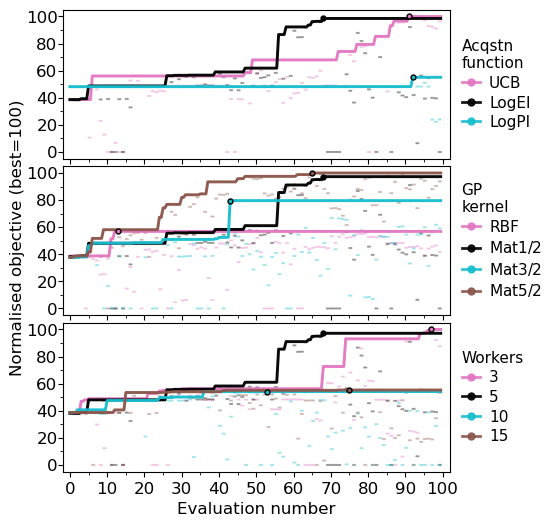

In [132]:
# load different BO runs for different settings

acq_map = {
    'ucb': ("UCB", 'tab:pink'),
    'lei': ("LogEI", 'black'),
    'lpi': ("LogPI", 'tab:cyan'),
}

ker_map = {
    'rbf': ("RBF", 'tab:pink'),
    'mat12': (r"Mat$1/2$", 'black'),
    'mat32': (r"Mat$3/2$", 'tab:cyan'),
    'mat52': (r"Mat$5/2$", 'tab:brown'),
}

cpu_map = {
    '3': ("3", 'tab:pink'),
    '5': ("5", 'black'),
    '10': ("10", 'tab:cyan'),
    '15': ("15", 'tab:brown')
}

style_map = {
    'ACQF': ("Acqstn\nfunction", acq_map),
    'Kernel': ("GP\nkernel", ker_map),
    'Workers': ("Workers", cpu_map)
}

ymin = 0
ms = '.'
ls = 'solid'

# baseline parameters
bl_suf = 'tr'
bl_acq = 'lei'
bl_ker = 'mat12'
bl_wrk = '5'
bl_stp = '100'

print("Baseline parameters:")
print(f"  Suffix: {bl_suf}")
print(f"  Acquisition function: {bl_acq}")
print(f"  Kernel: {bl_ker}")
print(f"  Workers: {bl_wrk}")
print(f"  Steps: {bl_stp}")

hyperpar_list = list(style_map.keys())
Nax = len(hyperpar_list)

fig,axs = plt.subplots(Nax,1,figsize=(5,Nax*2))

for iax, hyperpar in enumerate(hyperpar_list):
    ax = axs[iax]

    # determine best and worst objective
    jbest = -np.inf
    jwrst = np.inf
    jclip = -2
    xbest = 0
    kbest = None
    for hyperpar_val in style_map[hyperpar][1].keys():

        # baseline hyperparameters
        suf = bl_suf
        acq = bl_acq
        ker = bl_ker
        wrk = bl_wrk
        stp = bl_stp

        # set hyperparameter to vary
        if hyperpar == 'ACQF':
            acq = hyperpar_val
        elif hyperpar == 'Kernel':
            ker = hyperpar_val
        elif hyperpar == 'Workers':
            wrk = hyperpar_val

        bo_dir = f"{SIM_DIR}/bayesopt_infer_{suf}_{ker}_{acq}_{wrk}_{stp}/"
        if bo_dir in bo_cache:
            bo = bo_cache[bo_dir]
        else:
            bo = get_bo_run(bo_dir)
        if bo is None:
            print(f"BO run not found for {acq} with {wrk} CPUs")
            continue

        bo_cache[bo_dir] = bo
        print(bo_dir)
        print("\t",bo['config']['ref_config'])

        log        = bo['log']
        for isim in range(len(log)):
            yv = log[isim]['y_value']
            if yv < -19.9:
                continue
            yv = max(yv, jclip)
            jwrst = min(jwrst, yv)
            if yv > jbest:
                jbest = yv
                xbest = isim + 0.5
                kbest = hyperpar_val
        
    print(f"Best objective for {hyperpar}: {jbest:.2f} at {xbest} s")
    print(f"Worst objective for {hyperpar}: {jwrst:.2f}")

    for hyperpar_val in style_map[hyperpar][1].keys():

        # baseline hyperparameters
        suf = bl_suf
        acq = bl_acq
        ker = bl_ker
        wrk = bl_wrk
        stp = bl_stp

        # set hyperparameter to vary
        if hyperpar == 'ACQF':
            acq = hyperpar_val
        elif hyperpar == 'Kernel':
            ker = hyperpar_val
        elif hyperpar == 'Workers':
            wrk = hyperpar_val

        # ncpu = int(wrk)
        ncpu = 1

        lbl = style_map[hyperpar][1][hyperpar_val][0]
        col = style_map[hyperpar][1][hyperpar_val][1]

        # get data        
        bo_dir = f"{SIM_DIR}/bayesopt_infer_{suf}_{ker}_{acq}_{wrk}_{stp}/"
        if bo_dir not in bo_cache:
            print(f"BO run not found for {acq} with {wrk} CPUs")
            continue
        bo = bo_cache[bo_dir]
        log        = bo['log']
        helps      = bo['helps']
        confs      = bo['confs']
        obs_this   = bo['obs']  # observables for this BO run
        prs_this   = bo['prs']  # parameters ranges for this BO run

        # get values for each worker process
        xarr, yarr = [], []
        for isim in range(len(log)):
            yv = log[isim]['y_value']
            if yv < -19.9:
                continue
            yv = max(yv, jclip)
            yv = (yv - jwrst) / (jbest - jwrst) * 100

            t0 = isim
            t1 = isim + 0.5

            # calculate time with nCPUs
            t0 = t0*ncpu
            t1 = t1*ncpu

            xarr.extend([t0, t1])
            yarr.extend([yv, yv])

        yarr = np.clip(yarr, jclip, None)
        xarr = np.array(xarr)

        # scatter all the data
        ax.scatter(xarr, yarr, color=col, alpha=0.4, edgecolor='none',
                       s=10, zorder=10, lw=1, marker=ms)

        # line plot showing max over time
        mask = np.argsort(xarr)
        xarr = xarr[mask]
        yarr = yarr[mask]
        yarr = np.maximum.accumulate(yarr)
        ax.plot(xarr, yarr, color=col, alpha=0.96, lw=2.1, zorder=20, linestyle=ls)

        # best point for this combination of hyperparameters
        ibest = np.argmax(yarr)
        ax.scatter(xarr[ibest], yarr[ibest], color=col, edgecolor='k',
                   s=50, zorder=30, lw=1, marker=ms)

        # legend entry
        ax.plot([], [], color=col, ls=ls, label=lbl, lw=2, marker=ms, markersize=10, alpha=0.9)

    ax.legend(loc='center left', bbox_to_anchor=(1.01,0.5), 
              title=style_map[hyperpar][0], title_fontsize=11, alignment='left',
               handlelength=1.2, handletextpad=0.6, labelspacing=0.3, columnspacing=1.5,
                fontsize=11, framealpha=1.0, edgecolor='none', borderpad=0)

    # for (ann_s, ann_x) in [("soon", 0.03), ("late", 0.97)]:
    #     for (ann_l, ann_y) in [("Good", 0.97), ("Bad", 0.03)]:
    #         ha = 'left' if ann_x < 0.5 else 'right'
    #         va = 'top' if ann_y > 0.5 else 'bottom'
    #         txt = f"{ann_l}, {ann_s}"

    #         ax.text(ann_x, ann_y, txt, transform=ax.transAxes, fontsize=11, ha=ha, va=va, zorder=99,
    #             color='k')

    # ax.set_ylim(-5, 105)
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.yaxis.set_minor_locator(MultipleLocator(10))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.0f"))
    ax.tick_params(axis='y', which='major', pad=0.1, labelsize=font["size"])

    ax.set_xlim(left=-2, right=102)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(5))

    # ax.grid(which='major', axis='x', alpha=0.5, lw=0.8)

    if iax < Nax - 1:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Evaluation number")


fig.supylabel("Normalised objective (best=100)", fontsize=font["size"])
fig.subplots_adjust(hspace=0.05)
fig.savefig("output/bo_perf.pdf", bbox_inches='tight', dpi=DPI, pad_inches=0.01)
plt.show()